In [1]:
"""
I am using the concept of importing the file from the file explorer directly instead of the URL
"""
import pandas as pd
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset.csv


In [3]:
"""
Imprted the csv file using th read() func
Displayed the first 5 rows from the dataset with all the columns
"""

df = pd.read_csv("dataset.csv")
df.head()



,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
"""
Info() function will display all the fields of the CSV and their datstypes
"""

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

In [5]:
"""
Identifying which field is the dependent variable and which is the independent variable
All the columns except the target columns are the independent variables
So we are going to drop the target column from the dataset
"""
X = df.drop('Target', axis=1)
y = df['Target']


In [6]:
# Step 5: Train-Test Split
from sklearn.model_selection import train_test_split

"""
I am going to use 80% for the training purposes &
20% for the testing purposes
"""
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

"""
We are going to get Trainig set as 3539 rows &
885 rows for the testing
"""
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (3539, 34)
Testing set size: (885, 34)


In [7]:
# Step 6: Model Selection
from sklearn.ensemble import RandomForestClassifier

"""
We are setting the random state as 42 because
every time the notebook is run, same choices will be generated for the training and testing data
which makes the model predictable and the results consistent
"""
model = RandomForestClassifier(random_state=42)


In [8]:
# Step 7: Model Training
model.fit(X_train, y_train)

print("✅ Model training complete using Random Forest Classifier!")


✅ Model training complete using Random Forest Classifier!


In [15]:
"""
Number of decision making trees made in the forest
More the no of trees -> better performance
"""
print("Number of trees:", len(model.estimators_))

# Feature importance (to see which factors influence prediction most)
import pandas as pd
#Determines how much important is each field in the model prediction
feature_importance = pd.Series(model.feature_importances_, index=X_train.columns)
print("\nTop 10 Important Features:")
#We have displayed all of the field and their importance in the model prediction
print(feature_importance.sort_values(ascending=False).head(34))


Number of trees: 100

Top 10 Important Features:
Curricular units 2nd sem (approved)               0.139524
Curricular units 2nd sem (grade)                  0.108936
Curricular units 1st sem (approved)               0.093029
Curricular units 1st sem (grade)                  0.074309
Curricular units 2nd sem (evaluations)            0.048938
Age at enrollment                                 0.042033
Curricular units 1st sem (evaluations)            0.039941
Tuition fees up to date                           0.038683
Course                                            0.037771
Father's occupation                               0.033178
Mother's occupation                               0.030291
GDP                                               0.027255
Unemployment rate                                 0.025785
Father's qualification                            0.025599
Mother's qualification                            0.025458
Application mode                                  0.025397
Inflati

In [10]:
# Step 8: Model Prediction

# Predict on the training data
y_pred_train = model.predict(X_train)

# Predict on the testing data
y_pred_test = model.predict(X_test)

print("✅ Model prediction completed for both training and testing sets!")


✅ Model prediction completed for both training and testing sets!


In [ ]:
# Step 9: Model Evaluation for Classification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

"""
Evaluate model training on true value and predictd value and return a number between 0 & 1
"""
train_accuracy = accuracy_score(y_train, y_pred_train)
print("Training Accuracy:", train_accuracy)

"""
Evaluate model on testing data & compare the true value and the predicted value and return a number between 0 & 1
"""
test_accuracy = accuracy_score(y_test, y_pred_test)
print("Testing Accuracy:", test_accuracy)

# Detailed evaluation report
print("\nClassification Report (on Test Set):")
print(classification_report(y_test, y_pred_test))

# Confusion matrix - A matrix (table) that compares actual labels (rows) with predicted labels (columns).
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))


Training Accuracy: 1.0
Testing Accuracy: 0.7728813559322034

Classification Report (on Test Set):
              precision    recall  f1-score   support

     Dropout       0.84      0.76      0.80       316
    Enrolled       0.53      0.32      0.40       151
    Graduate       0.78      0.94      0.85       418

    accuracy                           0.77       885
   macro avg       0.72      0.68      0.68       885
weighted avg       0.76      0.77      0.76       885


Confusion Matrix:
[[241  28  47]
 [ 38  49  64]
 [  8  16 394]]


In [12]:
# Step 11: Combine Results (Single Model Version)

import pandas as pd

# Store results of the Random Forest model
results_rf = pd.DataFrame({
    'Model': ['Random Forest Classifier'],
    'Training Accuracy': [accuracy_score(y_train, y_pred_train)],
    'Testing Accuracy': [accuracy_score(y_test, y_pred_test)]
})

print("✅ Random Forest Results:")
print(results_rf)


✅ Random Forest Results:
                      Model  Training Accuracy  Testing Accuracy
0  Random Forest Classifier                1.0          0.772881


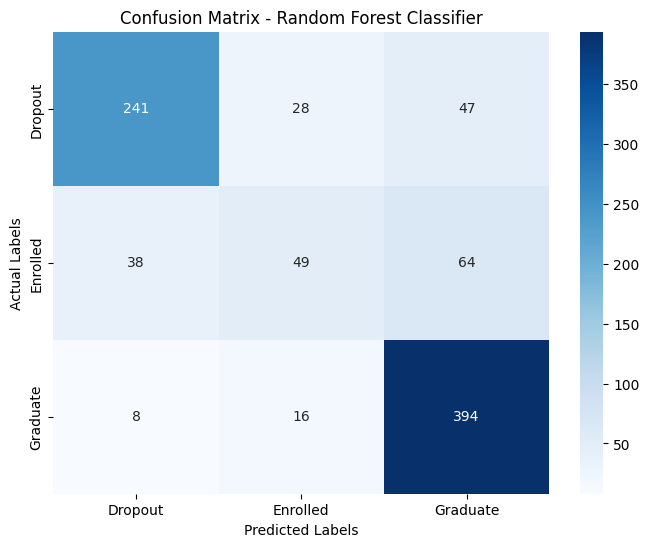

In [13]:
# Step 12: Data Visualization (Confusion Matrix)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Get unique class names
class_names = np.unique(y_test)

# Plot confusion matrix heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()


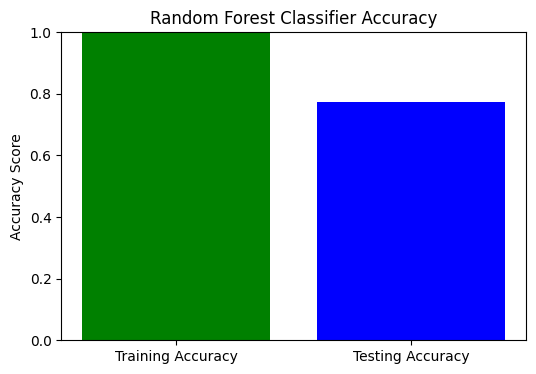

In [14]:
# Accuracy bar chart
plt.figure(figsize=(6,4))
plt.bar(['Training Accuracy', 'Testing Accuracy'],
        [accuracy_score(y_train, y_pred_train),
         accuracy_score(y_test, y_pred_test)],
        color=['green', 'blue'])

plt.title('Random Forest Classifier Accuracy')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)
plt.show()
